# AI61002: Deep Learning Foundations and Applications
## Assignment 2: Convolutional Neural Networks
### Name: Biswas Tuhin Manik
### Roll Number: 22MT3AI38
---

## Imports

Import all the required libraries upfront and configure the computing device

- torch / torch.nn / torch.optim — core PyTorch for tensor ops, model layers, and optimizers
- torchvision — provides the EuroSAT dataset and image transform utilities
- numpy / matplotlib / seaborn — numerical operations and visualisation
- scikit-learn — evaluation metrics: precision, recall, confusion matrix
- copy.deepcopy — used to save a fully independent copy of the best model weights

A fixed random seed (`SEED = 42`) is set for both NumPy and PyTorch to ensure the dataset split and weight initialisation are reproducible.

In [1]:
import torch                                          # core PyTorch library
import torch.nn as nn                                 # neural network layers (Conv2d, Linear, etc.)
import torch.nn.functional as F                       # functional ops like relu, used in forward pass
import torch.optim as optim                           # optimizers: Adam, SGD, etc.
from torch.utils.data import DataLoader, Subset       # DataLoader batches data; Subset selects indices

import torchvision                                    # computer vision datasets and utilities
import torchvision.transforms as transforms           # image preprocessing and augmentation
from torchvision.datasets import EuroSAT              # EuroSAT satellite image dataset

import numpy as np                                    # numerical operations, array manipulation
import matplotlib.pyplot as plt                       # plotting graphs and images
import seaborn as sns                                 # statistical visualisation (confusion matrix heatmap)
from sklearn.metrics import precision_score, recall_score, confusion_matrix  # evaluation metrics
from copy import deepcopy                             # creates fully independent copies of objects

# ──────────────── Device setup ───────────────────────────────────
# use GPU(cuda) if available, otherwise CPU
# this laptop: NVIDIA GeForce RTX 3050 Laptop GPU is detected as cuda:0
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

# ─────────────── Reproducibility ─────────────────────────────────
# setting the same seed, thus ensuring identical random shuffles and weight inits every run
SEED = 42
np.random.seed(SEED)       # fixes NumPy random number generator
torch.manual_seed(SEED)    # fixes PyTorch random number generator

Using device: cuda



## Question 1
### Load EuroSAT Dataset and Show Class Distribution

EuroSAT is a dataset for land-use and land-cover classification built from Sentinel-2 satellite imagery. It contains:-
- **27,000 labelled RGB images**, each of size **64×64 pixels**
- **10 classes** for different land types: forests, rivers, highways, industrial areas, etc.

It's observed to have class imbalance, where some classes have significantly more samples than others, thus can bias a model towards predicting majority classes more often, inflating overall accuracy while performing poorly on minority classes.

Therefore, checking the distribution before training.

Total samples : 27000
Num classes   : 10
Image size    : 64 x 64 x 3  (RGB)

Class Distribution:
   0. AnnualCrop                    : 3000
   1. Forest                        : 3000
   2. HerbaceousVegetation          : 3000
   3. Highway                       : 2500
   4. Industrial                    : 2500
   5. Pasture                       : 2000
   6. PermanentCrop                 : 2500
   7. Residential                   : 3000
   8. River                         : 2500
   9. SeaLake                       : 3000


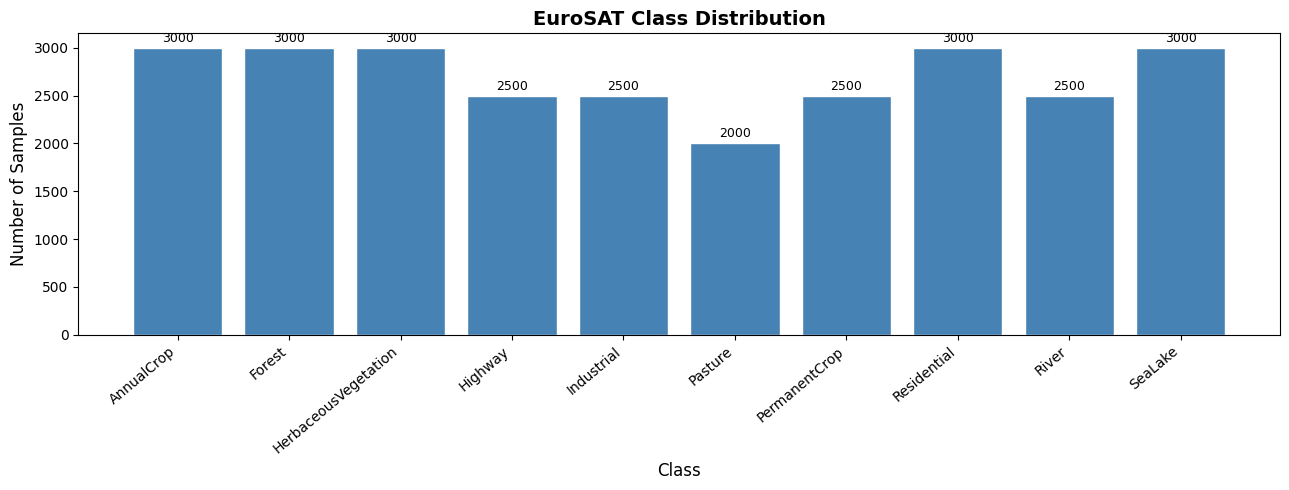

In [2]:
# ────────── Q1: Load EuroSAT and show class distribution ─────────────────────

# minimal transform - only convert PIL image to tensor, no augmentation or normalization
# for initial inspection only. proper transforms are defined in Q3
base_transform = transforms.Compose([
    transforms.ToTensor(),   # converts PIL image [0,255] -> float tensor [0.0, 1.0]
])

# download EuroSAT to ./data folder (set download=False after the first run)
full_dataset = EuroSAT(root='./data', transform=base_transform, download=True)

class_names = full_dataset.classes           # list of the 10 class name strings
targets     = np.array(full_dataset.targets) # integer label (0–9) for every sample in the dataset

print(f'Total samples : {len(full_dataset)}')
print(f'Num classes   : {len(class_names)}')
print(f'Image size    : 64 x 64 x 3  (RGB)')

# count samples per class by checking how many targets equal each class index
print('\nClass Distribution:')
class_counts = []                            # store count for each class
for i, cls in enumerate(class_names):
    count = int((targets == i).sum())        # count no. of samples having label i
    class_counts.append(count)              # append to list for plotting later
    print(f'  {i:>2}. {cls:<30s}: {count}')

# ──────────────── Bar chart for class distribution ───────────────────────────────
fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(class_names, class_counts, color='steelblue', edgecolor='white')

# annotate each bar with its exact sample count above the bar
for bar, cnt in zip(bars, class_counts):
    ax.text(bar.get_x() + bar.get_width()/2,   
            bar.get_height() + 30,              
            str(cnt), ha='center', va='bottom', fontsize=9)

ax.set_xlabel('Class', fontsize=12)
ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('EuroSAT Class Distribution', fontsize=14, fontweight='bold')
plt.xticks(rotation=40, ha='right')   # rotate x-axis labels
plt.tight_layout()
plt.show()

The bar chart shows that EuroSAT is slightly imbalanced:

| Group | Classes | Samples in each |
|---|---|---|
| Majority | AnnualCrop, Forest, HerbaceousVegetation, Residential, SeaLake | 3,000 |
| Medium | Highway, Industrial, PermanentCrop, River | 2,500 |
| Minority | Pasture | 2,000 |

It means **Pasture may have slightly lower recall** since the model sees fewer examples of it during training.
We will verify this in Q6 when computing per-class precision and recall.

## Question 2
### Train / Validation / Test Split (70% - 15% - 15%)

We use three splits:

| Split | Fraction | Size | Purpose |
|---|---|---|---|
| Train | 70% | 18,900 | Learn model weights through gradient descent |
| Validation | 15% | 4,050 | Monitor training, detect overfitting, tune hyperparameters |
| Test | 15% | 4,050 | Final unbiased performance estimate |

We used `np.random.permutation` with a fixed seed (`SEED=42`) ensuring the exact same split. 

`permutation` randomly shuffles indices so each split gets a representative mix of all classes

`torch.utils.data.Subset` wraps the existing dataset and only exposes the selected indices.
This avoids duplicating data in memory and allows applying **different transforms** 
(augmentation on train, none on val/test) to the same underlying dataset.

In [3]:
# ── Q2: Train / Val / Test split ────────────────────────────────────────────

n       = len(full_dataset)          # total no. of samples = 27,000
indices = np.random.permutation(n)   # randomly shuffle all indices

train_end = int(0.70 * n)            # 70% of 27000 = 18900 → end index for train
val_end   = int(0.85 * n)            # 85% of 27000 = 22950 → end index for val (85-70=15%)

train_idx = indices[:train_end]      # first 70%  → training indices
val_idx   = indices[train_end:val_end]  # next 15% → validation indices
test_idx  = indices[val_end:]        # last 15%   → test indices

print(f'Total samples : {n}')
print(f'Train size    : {len(train_idx)}  ({len(train_idx)/n*100:.1f} %)')
print(f'Val size      : {len(val_idx)}   ({len(val_idx)/n*100:.1f} %)')
print(f'Test size     : {len(test_idx)}   ({len(test_idx)/n*100:.1f} %)')

# ──────────── Sanity check: verify no overlap between splits ─────────────────
# converting to sets and intersecting should give empty sets if splits are disjoint
assert len(set(train_idx) & set(val_idx))  == 0, 'Train/Val overlap!'   # & = set intersection
assert len(set(train_idx) & set(test_idx)) == 0, 'Train/Test overlap!'
assert len(set(val_idx)   & set(test_idx)) == 0, 'Val/Test overlap!'
print('\nSanity check passed — splits are disjoint.')

Total samples : 27000
Train size    : 18900  (70.0 %)
Val size      : 4050   (15.0 %)
Test size     : 4050   (15.0 %)

Sanity check passed — splits are disjoint.


The split produces exactly the expected sizes:
- **18,900 training samples** - the model learn diverse features from all 10 classes
- **4,050 validation samples** - used after each epoch to detect if the model starts overfitting
- **4,050 test samples** - held completely aside and used only in Q6 for final evaluation

The sanity check confirms the three splits are **perfectly disjoint** — no sample appears in more than one split. Ensuring the evaluation is unbiased.

## Computing the Mean and Standard Deviation from the Training Data

Before creating DataLoaders, we compute the **channel-wise mean and standard deviation** from the training split only.

We computed from training data only, as using val or test data statistics would lead to **data leakage**, i.e., the model indirectly gains information about the test set.

We normalized, as the `Normalize` transform in Q3 applies: $x_{norm} = \frac{x - \mu}{\sigma}$ per channel.

This ensures the input values are centered around 0 with unit variance, Gradients are more stable during backpropagation and training converges faster and more reliably

#### Why per-channel?
Each RGB channel has different natural brightness ranges in satellite imagery (e.g., the green channel is dominant in vegetation areas). Normalising them independently preserves this relative information.

In [4]:
# ───────────── Compute Mean & Std from training data only ────────────────────

# loading training images with ONLY ToTensor — no normalization, no augmentation
# we need raw pixel values in [0,1] to compute statistics
compute_transform = transforms.Compose([transforms.ToTensor()])
compute_dataset   = EuroSAT(root='./data', transform=compute_transform, download=False)
compute_subset    = Subset(compute_dataset, train_idx)  # only training indices, not val/test
compute_loader    = DataLoader(compute_subset, batch_size=256,  # large batch for speed
                               shuffle=False, num_workers=2)    # no shuffle needed for stats

mean      = torch.zeros(3)   # will accumulate per-channel mean sums  [R, G, B]
std       = torch.zeros(3)   # will accumulate per-channel std sums   [R, G, B]
n_samples = 0                # total number of images processed

for imgs, _ in compute_loader:
    batch_size = imgs.size(0)                    # number of images in this batch
    imgs = imgs.view(batch_size, 3, -1)          # reshape (B,3,64,64) → (B,3,4096) to flatten spatial
    mean += imgs.mean(dim=2).sum(dim=0)          # mean over 4096 pixels per image, sum over batch
    std  += imgs.std(dim=2).sum(dim=0)           # std over 4096 pixels per image, sum over batch
    n_samples += batch_size                      # accumulate total image count

mean /= n_samples    # divide accumulated sum by total images → average of per-image means
std  /= n_samples    # divide accumulated sum by total images → average of per-image stds

print(f'MEAN = [{mean[0]:.4f}, {mean[1]:.4f}, {mean[2]:.4f}]')
print(f'STD  = [{std[0]:.4f},  {std[1]:.4f},  {std[2]:.4f}]')

# Store as Python lists for use in transforms.Normalize() in Q3
MEAN = mean.tolist()
STD  = std.tolist()

MEAN = [0.3446, 0.3804, 0.4080]
STD  = [0.0916,  0.0653,  0.0554]


## Question 3
### DataLoaders with Data Augmentation

We augment training data, as Deep CNNs require large amounts of diverse training data. With only ~19k training images, the model risks overfitting rather than learning general features.

Data augmentation applies **label-preserving random transformations** that artificially increase the effective variety of training data without collecting new images.

| Augmentation | Parameters | Rationale |
|---|---|---|
| `RandomHorizontalFlip` | p=0.5 | Satellite images have no canonical left-right orientation |
| `RandomVerticalFlip` | p=0.5 | Satellite images have no canonical up-down orientation |
| `RandomRotation` | 30° | Rotational invariance — fields and forests look the same at any angle |
| `RandomResizedCrop` | scale=(0.7,1.0) | Simulates zoom variation and forces learning of partial features |

We did not applied augmentation on val/test.
Val and test sets must be **deterministic** — applying random transforms would give different results each evaluation, making it impossible to compare across epochs or experiments. 
They use only `Resize` and `Normalize`.

#### DataLoader parameters
- `batch_size=128` - safe for our 4GB VRAM on RTX 3050
- `num_workers=6` - half of 12 logical CPU cores, background processes prefetch data while GPU trains
- `pin_memory=True` - allocates data in page-locked memory for faster CPU→GPU transfer
- `persistent_workers=True` - keeps workers alive between epochs, eliminating startup delay

Train batches : 148
Val batches   : 32
Test batches  : 32


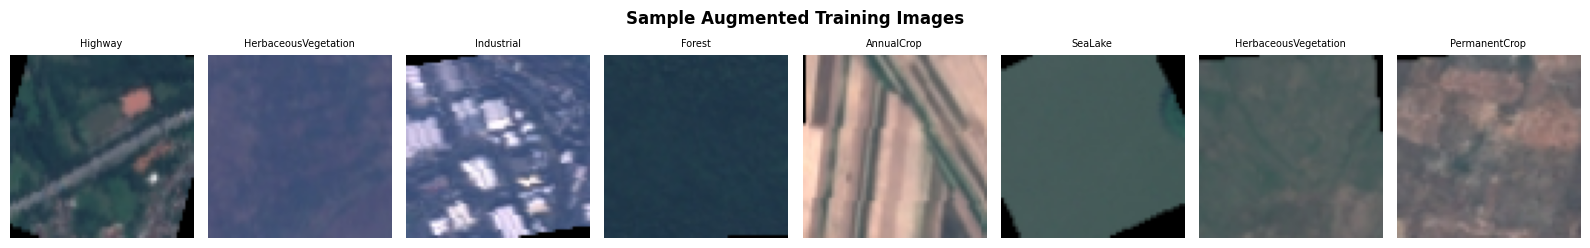

In [5]:
# ────────────── Q3: Transforms and DataLoaders ──────────────────────────────

# ─────────────────── Training transform - WITH augmentation ──────────────────
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),          # 50% chance to flip image left-right
    transforms.RandomVerticalFlip(p=0.5),            # 50% chance to flip image top-bottom
    transforms.RandomRotation(degrees=30),           # random rotation between -30° and +30°
    transforms.RandomResizedCrop(size=64,            # randomly crop a region then resize back to 64×64
                                  scale=(0.7, 1.0)), # crop covers 70%–100% of original area
    transforms.ToTensor(),                           # PIL image → float tensor, values in [0,1]
    transforms.Normalize(mean=MEAN, std=STD),        # normalize each channel: (x - mean) / std
])

# ──────────────────── Eval transform - NO augmentation ───────────────────────
# Val and test images must be processed identically every time for fair evaluation
eval_transform = transforms.Compose([
    transforms.Resize(64),                           # ensure image is 64×64 (already is, but safe)
    transforms.ToTensor(),                           # PIL image → float tensor
    transforms.Normalize(mean=MEAN, std=STD),        # same normalization as training
])

# load dataset twice with different transforms
# subset will then select only the indices belonging to each split
train_dataset_full = EuroSAT(root='./data', transform=train_transform, download=False)
eval_dataset_full  = EuroSAT(root='./data', transform=eval_transform,  download=False)

# create subsets: each subset wraps the full dataset but only exposes specific indices
train_subset = Subset(train_dataset_full, train_idx)  # 18,900 training samples with augmentation
val_subset   = Subset(eval_dataset_full,  val_idx)    # 4,050 val samples without augmentation
test_subset  = Subset(eval_dataset_full,  test_idx)   # 4,050 test samples without augmentation

BATCH_SIZE = 128   # no. of images processed together in one forward & backward pass

# ────────────────── Create DataLoaders ───────────────────────────────────────
train_loader = DataLoader(
    train_subset,
    batch_size=BATCH_SIZE,
    shuffle=True,              # shuffle training data each epoch to prevent order-based memorisation
    num_workers=6,             # 6 background CPU processes to prefetch and preprocess batches
    pin_memory=True,           # pin memory for faster CPU→GPU transfer
    persistent_workers=True    # keep workers alive between epochs (eliminates startup delay)
)
val_loader = DataLoader(
    val_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,             # no shuffling needed for evaluation
    num_workers=6,
    pin_memory=True,
    persistent_workers=True
)
test_loader = DataLoader(
    test_subset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=6,
    pin_memory=True,
    persistent_workers=True
)

print(f'Train batches : {len(train_loader)}')
print(f'Val batches   : {len(val_loader)}')
print(f'Test batches  : {len(test_loader)}')

# ───────── visualise a sample of augmented training images ───────────────────
imgs, labels = next(iter(train_loader))   # grab one batch from the training loader
imgs_show    = imgs[:8]                   # take only the first 8 images for display

# unnormalise images for display: reverse the (x - mean)/std transform
mean_t = torch.tensor(MEAN).view(3, 1, 1)   # shape (3,1,1) for broadcasting over (3,H,W)
std_t  = torch.tensor(STD ).view(3, 1, 1)
imgs_show = (imgs_show * std_t + mean_t).clamp(0, 1)   # clamp keeps values in valid [0,1] range

fig, axes = plt.subplots(1, 8, figsize=(16, 2.5))
for ax, img, lbl in zip(axes, imgs_show, labels[:8]):
    ax.imshow(img.permute(1, 2, 0).numpy())   # permute (C,H,W) → (H,W,C) for matplotlib
    ax.set_title(class_names[lbl.item()], fontsize=7)
    ax.axis('off')
plt.suptitle('Sample Augmented Training Images', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

The visualised sample images show the effect of augmentation:
- Some images appear **flipped or rotated** compared to the raw dataset
- Some appear **zoomed in** (RandomResizedCrop effect - partial view of the original scene)
- Despite these changes, the **class label remains correct**

The DataLoader configuration gives:
- **148 training batches** (18,900 ÷ 128 ≈ 148) — the model sees all training images once per epoch
- **32 val/test batches** each (4,050 ÷ 128 ≈ 32)

With `persistent_workers=True`, the startup delay between epochs is eliminated — workers stay warm and ready to load the next batch immediately.

---
## Question 4
### Fully Convolutional Neural Network with Residual Connections, 1×1 Conv, and GAP

#### Design Requirements

**1. Residual Connections**

Standard deep networks suffer from the **vanishing gradient problem**. Residual connections solve this by adding a shortcut:
$$\mathbf{y} = F(\mathbf{x}, \{W_i\}) + \mathbf{x}$$
The `+ x` creates a direct gradient highway, allowing gradients to flow back without passing through conv layers.

**2. 1×1 Convolution**

A convolution with `kernel_size=1` operates on one spatial position at a time across all channels, thus acting as a **channel-wise mixer** - learning weighted combinations of feature maps without changing spatial dimensions. 

We use it to compress 128 channels -> 64 before GAP, reducing parameters.

**3. Global Average Pooling (GAP)**

GAP replaces the traditional Flatten + large FC layer. It computes the spatial average of each feature map:
$$\text{GAP}(x_c) = \frac{1}{H \times W} \sum_{i,j} x_c(i,j)$$
This reduces a `(64, 16, 16)` tensor to a `(64,)` vector with **no parameters**, acting as a strong regulariser.

#### Architecture Summary
```
Input  (3 × 64 × 64)
  → Stem Conv  3→32                    [64×64]
  → Stage 1: ResBlock(32→32) × 2       [64×64] - basic features
  → Stage 2: ResBlock(32→64, s=2) × 2  [32×32] - deeper features
  → Stage 3: ResBlock(64→128,s=2) × 2  [16×16] - complex features
  → 1×1 Conv  128→64                   [16×16] - channel compression
  → GAP                                [1×1]   - spatial collapse
  → Linear 64→10                               - classification
```

In [6]:
# ──────────────── Q4: Model Definition ───────────────────────────────────────

class ResBlock(nn.Module):
    """
    Basic Residual Block:
        Main path  : Conv3×3 → BN → ReLU → Conv3×3 → BN
        Shortcut   : identity (if shapes match) OR 1×1 Conv (if shapes differ)
        Output     : main_path + shortcut → ReLU
    """
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()   # initialise parent nn.Module class

        # ────────────── Main path (the transformation F(x)) ─────────────────
        # First conv: may change channels and/or spatial size (if stride=2)
        self.conv1 = nn.Conv2d(in_ch, out_ch, kernel_size=3,
                               stride=stride, padding=1, bias=False)
        # padding=1 keeps spatial size same (when stride=1); bias=False because BN handles shift
        self.bn1   = nn.BatchNorm2d(out_ch)   # normalize activations for stable training

        # Second conv: always stride=1, keeps spatial size unchanged
        self.conv2 = nn.Conv2d(out_ch, out_ch, kernel_size=3,
                               stride=1, padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)

        # ── Shortcut path ───────────────────────────────────────────────────
        # Default: identity shortcut (x passes through unchanged)
        self.shortcut = nn.Sequential()

        # If stride≠1 OR channels change, dimensions don't match for addition
        # → use 1×1 conv to project x to the correct shape
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=1,   # 1×1 conv: change channels only
                          stride=stride, bias=False),      # stride matches main path
                nn.BatchNorm2d(out_ch),
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))   # Conv → BN → ReLU  (first layer)
        out = self.bn2(self.conv2(out))         # Conv → BN          (no ReLU before addition)
        out = out + self.shortcut(x)            # residual addition: F(x) + x
        return F.relu(out)                      # final ReLU after addition


class FullyConvNet(nn.Module):
    """
    Fully Convolutional NN for EuroSAT (10-class classification).
    No large FC layers — uses GAP for spatial pooling and 1×1 conv for channel reduction.
    """
    def __init__(self, num_classes=10):
        super().__init__()

        # ────────────── Stem: entry point ───────────────────────────────────
        # Converts raw RGB (3 channels) to 32 feature maps, preserving 64×64 spatial size
        self.stem = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, stride=1, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),   # inplace=True saves memory by modifying tensor directly
        )

        # ────────── Stage 1: basic feature learning ─────────────────────────
        # 32 channels, spatial size stays 64×64 (no downsampling)
        # learns edges, colours, simple textures
        self.stage1 = nn.Sequential(
            ResBlock(32, 32),   # identity shortcut (same shape)
            ResBlock(32, 32),   # identity shortcut (same shape)
        )

        # ─────────────── Stage 2: intermediate feature learning ──────────────
        # 64 channels, spatial 64×64 -> 32×32 (stride=2 halves spatial dims)
        # learns texture combinations, pattern repetitions
        self.stage2 = nn.Sequential(
            ResBlock(32, 64, stride=2),   # 1×1 projection shortcut (channels 32->64, size /2)
            ResBlock(64, 64),             # identity shortcut
        )

        # ──────────── Stage 3: high-level feature learning ───────────────────
        # 128 channels, spatial 32×32 -> 16×16 (stride=2 halves spatial dims)
        # learns complex object-level patterns specific to each land class
        self.stage3 = nn.Sequential(
            ResBlock(64, 128, stride=2),   # 1×1 projection shortcut (channels 64->128, size /2)
            ResBlock(128, 128),            # identity shortcut
        )

        # ────────────── 1×1 Convolution: channel bottleneck ──────────────────
        # Reduces 128 channels -> 64 channels without changing spatial size (16×16)
        # Learns optimal channel combinations; reduces classifier parameters
        self.conv1x1 = nn.Sequential(
            nn.Conv2d(128, 64, kernel_size=1, bias=False),   # 1×1 = look at one pixel across all channels
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )

        # ────────────── Global Average Pooling ────────────────────────────────
        # Collapses each 16×16 feature map to a single scalar (its average)
        # Output: (B, 64, 1, 1) - one number per feature map per sample
        # AdaptiveAvgPool2d(1) means output spatial size = 1×1 regardless of input size
        self.gap = nn.AdaptiveAvgPool2d(output_size=1)

        # ───────────── Classification head ────────────────────────────────────
        # Single linear layer: 64-d feature vector -> 10 class logit scores
        self.classifier = nn.Linear(64, num_classes)

    def forward(self, x):
        x = self.stem(x)              # (B, 3,   64, 64) -> (B, 32,  64, 64)
        x = self.stage1(x)            # (B, 32,  64, 64) -> (B, 32,  64, 64)  no size change
        x = self.stage2(x)            # (B, 32,  64, 64) -> (B, 64,  32, 32)  ×0.5 spatial
        x = self.stage3(x)            # (B, 64,  32, 32) -> (B, 128, 16, 16)  ×0.5 spatial
        x = self.conv1x1(x)           # (B, 128, 16, 16) -> (B, 64,  16, 16)  1×1 conv
        x = self.gap(x)               # (B, 64,  16, 16) -> (B, 64,   1,  1)  GAP
        x = x.view(x.size(0), -1)     # (B, 64,   1,  1) -> (B, 64)           flatten
        x = self.classifier(x)        # (B, 64)          -> (B, 10)            logits
        return x


# ─────────────── Instantiate model and move to GPU ───────────────────────────
model = FullyConvNet(num_classes=len(class_names)).to(device)   # .to(device) moves all params to GPU
print(model)

# count parameters: p.numel() returns total elements in a tensor
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)  # p.requires_grad=True by default
print(f'\nTotal parameters     : {total_params:,}')
print(f'Trainable parameters : {trainable_params:,}')  # should equal total (no frozen layers)

# ────────────────── Dry run: verify output shape ──────────────────────────────
# Pass a dummy all-zero image through the model to confirm shapes are correct
dummy = torch.zeros(1, 3, 64, 64).to(device)   # fake single image on GPU
with torch.no_grad():                            # disable gradients — just checking shape
    out = model(dummy)
print(f'Output shape for a single image: {out.shape}  (expected [1, 10])')

FullyConvNet(
  (stem): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (stage1): Sequential(
    (0): ResBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (shortcut): Sequential()
    )
    (1): ResBlock(
      (conv1): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (

The model summary confirms the architecture is correctly built:
- **Total == Trainable parameters** - all layers are active and will be updated during training.
- **Output shape `[1, 10]`** - one set of 10 class logit scores per image 

The parameter count is deliberately small for EuroSAT:
- Large enough to learn complex satellite image features across 10 classes
- Small enough to avoid severe overfitting on the 18,900 training samples
- Trains efficiently

## Question 5
### Training the CNN with Adam Optimizer

#### Loss Function - Cross Entropy
Cross-Entropy Loss is the standard for multi-class classification:
$$\mathcal{L} = -\log(\hat{p}_{\text{true class}})$$
It penalises confident wrong predictions heavily and barely penalises confident correct predictions.

#### Optimizer — Adam
Adam maintains per-parameter adaptive learning rates using two moving averages:
- **First moment** $m_t$ - tracks gradient direction (like momentum)
- **Second moment** $v_t$ - tracks gradient magnitude (like RMSProp)

Update rule: $\theta \leftarrow \theta - \frac{\text{lr}}{\sqrt{v_t} + \epsilon} \cdot m_t$

Making Adam robust to learning rate choice and fast-converging.

#### Learning Rate Schedule - Cosine Annealing
The learning rate decays smoothly following a cosine curve over 30 epochs:
- **High LR early** -> large steps, fast exploration of loss landscape
- **Low LR late** -> tiny steps, fine-tuning around the best solution

#### Best Model Checkpointing
We save model weights whenever validation loss improves. After training we restore the best checkpoint - this prevents using a model that may have started overfitting in later epochs.

Epoch [01/30]  Train Loss: 1.1465  Acc: 62.82%  |  Val Loss: 0.7756  Acc: 73.56%  |  LR: 0.000997  ← best model saved


Epoch [02/30]  Train Loss: 0.7139  Acc: 76.06%  |  Val Loss: 0.8103  Acc: 72.02%  |  LR: 0.000989


Epoch [03/30]  Train Loss: 0.5559  Acc: 81.37%  |  Val Loss: 0.5914  Acc: 81.31%  |  LR: 0.000976  ← best model saved


Epoch [04/30]  Train Loss: 0.4384  Acc: 85.68%  |  Val Loss: 0.7339  Acc: 78.35%  |  LR: 0.000957


Epoch [05/30]  Train Loss: 0.3787  Acc: 87.41%  |  Val Loss: 0.3327  Acc: 89.26%  |  LR: 0.000933  ← best model saved


...

Epoch [26/30]  Train Loss: 0.0877  Acc: 97.13%  |  Val Loss: 0.1158  Acc: 95.95%  |  LR: 0.000043


Epoch [27/30]  Train Loss: 0.0832  Acc: 97.15%  |  Val Loss: 0.1111  Acc: 95.93%  |  LR: 0.000024


Epoch [28/30]  Train Loss: 0.0798  Acc: 97.36%  |  Val Loss: 0.0967  Acc: 96.64%  |  LR: 0.000011  ← best model saved


Epoch [29/30]  Train Loss: 0.0764  Acc: 97.44%  |  Val Loss: 0.0967  Acc: 96.74%  |  LR: 0.000003


Epoch [30/30]  Train Loss: 0.0796  Acc: 97.35%  |  Val Loss: 0.0970  Acc: 96.72%  |  LR: 0.000000

Training complete.  Best Val Loss: 0.0967


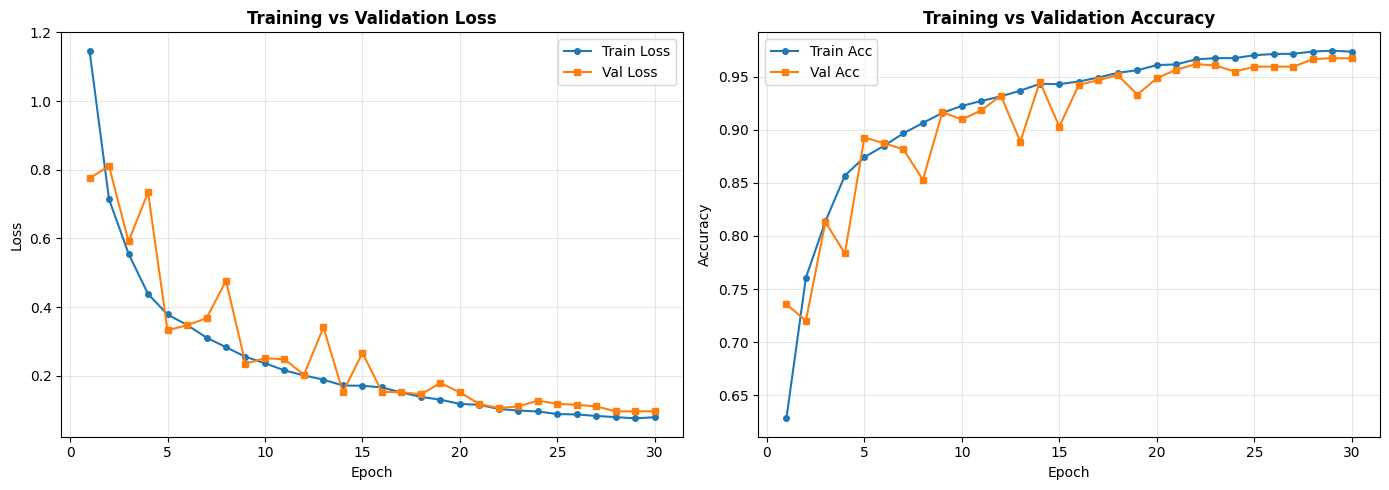

In [7]:
# ───────────── Q5: Training Loop ──────────────────────────────────────────────
from tqdm import tqdm   # progress bar library for terminal visualisation

# ──────────────── Hyperparameters ────────────────────────────────────────────
NUM_EPOCHS   = 30     # no. of complete passes through the training data
LR           = 1e-3   # initial learning rate for Adam (0.001)
WEIGHT_DECAY = 1e-4   # L2 regularisation strength — penalises large weights to prevent overfitting

# ───────────────────── Loss, Optimizer, Scheduler ────────────────────────────
criterion = nn.CrossEntropyLoss()   # combines Softmax + NLL loss; expects raw logits as input
optimizer = optim.Adam(
    model.parameters(),             # pass all trainable model parameters
    lr=LR,
    weight_decay=WEIGHT_DECAY       # L2 penalty added to loss: total_loss = CE_loss + λ·||θ||²
)
scheduler = optim.lr_scheduler.CosineAnnealingLR(
    optimizer,
    T_max=NUM_EPOCHS                # complete one cosine cycle over all 30 epochs
)

# ──────────────── Tracking lists for plotting ─────────────────────────────────
train_losses, val_losses = [], []   # store epoch-level loss for both phases
train_accs,   val_accs   = [], []   # store epoch-level accuracy for both phases

# ───────────────────── Best model checkpointing ───────────────────────────────
best_val_loss   = float('inf')                    # initialise to infinity so first epoch always improves it
best_model_wts  = deepcopy(model.state_dict())    # deepcopy ensures independence from live model weights

# ──────────────────── Main training loop ──────────────────────────────────────
for epoch in range(1, NUM_EPOCHS + 1):

    # ════════════════════════════════════════════════════════════════
    # TRAINING PHASE
    # ════════════════════════════════════════════════════════════════
    model.train()   # training mode: BatchNorm uses batch statistics; Dropout active (if any)
    running_loss, correct, total = 0.0, 0, 0   # accumulators reset each epoch

    # tqdm wraps the DataLoader and shows a live progress bar per epoch
    train_bar = tqdm(
        train_loader,
        desc=f'Epoch [{epoch:02d}/{NUM_EPOCHS}] Train',
        leave=False,     # bar disappears when epoch finishes (keeps terminal clean)
        ncols=100,       # bar width in characters
        colour='green'
    )

    for imgs, labels in train_bar:
        imgs, labels = imgs.to(device), labels.to(device)   # move batch to GPU

        optimizer.zero_grad()          # CRITICAL: clear gradients from previous batch
                                       # without this, gradients accumulate incorrectly
        outputs = model(imgs)          # forward pass: (B,3,64,64) → (B,10) logits
        loss    = criterion(outputs, labels)   # compute average cross-entropy loss over batch
        loss.backward()                # backpropagation: compute gradients for all parameters
        optimizer.step()               # update all parameters using Adam update rule

        running_loss += loss.item() * imgs.size(0)  # loss.item() is batch average, multiply back by batch size
        _, preds = outputs.max(1)                   # max along class dimension → predicted class indices
        correct  += preds.eq(labels).sum().item()   # count correct predictions in this batch
        total    += imgs.size(0)                    # accumulate total samples seen

        # Update progress bar with live running statistics
        train_bar.set_postfix({
            'loss' : f'{running_loss/total:.4f}',          # running average loss
            'acc'  : f'{correct/total*100:.2f}%',          # running accuracy
            'lr'   : f'{scheduler.get_last_lr()[0]:.6f}'   # current learning rate
        })

    # Compute epoch-level training metrics
    train_loss = running_loss / total   # average loss per sample this epoch
    train_acc  = correct / total        # fraction of correctly classified training samples
    train_losses.append(train_loss)
    train_accs.append(train_acc)

    # ════════════════════════════════════════════════════════════════
    # VALIDATION PHASE
    # ════════════════════════════════════════════════════════════════
    model.eval()   # eval mode: BatchNorm uses running statistics; Dropout disabled
    v_loss, v_correct, v_total = 0.0, 0, 0

    val_bar = tqdm(
        val_loader,
        desc=f'Epoch [{epoch:02d}/{NUM_EPOCHS}] Val  ',
        leave=False,
        ncols=100,
        colour='blue'
    )

    with torch.no_grad():   # disable gradient computation — not needed for evaluation, saves memory
        for imgs, labels in val_bar:
            imgs, labels = imgs.to(device), labels.to(device)
            outputs      = model(imgs)
            loss         = criterion(outputs, labels)
            v_loss      += loss.item() * imgs.size(0)   # accumulate total loss (not average)
            _, preds     = outputs.max(1)
            v_correct   += preds.eq(labels).sum().item()
            v_total     += imgs.size(0)

            val_bar.set_postfix({
                'loss' : f'{v_loss/v_total:.4f}',
                'acc'  : f'{v_correct/v_total*100:.2f}%'
            })

    # Compute epoch-level validation metrics
    val_loss = v_loss / v_total
    val_acc  = v_correct / v_total
    val_losses.append(val_loss)
    val_accs.append(val_acc)

    # ──────────────────── Save best model ─────────────────────────────────────
    if val_loss < best_val_loss:        # improvement in validation loss
        best_val_loss  = val_loss
        best_model_wts = deepcopy(model.state_dict())   # save independent copy of weights
        saved_str = '  ← best model saved'
    else:
        saved_str = ''

    scheduler.step()   # advance cosine LR schedule by one epoch

    # Print one clean summary line per epoch (train bar disappears, this line stays)
    print(
        f'Epoch [{epoch:02d}/{NUM_EPOCHS}]  '
        f'Train Loss: {train_loss:.4f}  Acc: {train_acc*100:.2f}%  |  '
        f'Val Loss: {val_loss:.4f}  Acc: {val_acc*100:.2f}%  |  '
        f'LR: {scheduler.get_last_lr()[0]:.6f}'
        f'{saved_str}'
    )

# ──────────────────── Restore best weights after training ────────────────────
model.load_state_dict(best_model_wts)   # roll back to the epoch with lowest val loss
print(f'\nTraining complete.  Best Val Loss: {best_val_loss:.4f}')

# ──────────────────── Plot training curves ────────────────────────────────────
epochs = range(1, NUM_EPOCHS + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss curve: shows how quickly the model learns and whether it overfits
axes[0].plot(epochs, train_losses, 'o-', label='Train Loss', markersize=4)
axes[0].plot(epochs, val_losses,   's-', label='Val Loss',   markersize=4)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].set_title('Training vs Validation Loss', fontweight='bold')
axes[0].legend()
axes[0].grid(alpha=0.3)

# Accuracy curve: shows the model's classification performance over time
axes[1].plot(epochs, train_accs, 'o-', label='Train Acc', markersize=4)
axes[1].plot(epochs, val_accs,   's-', label='Val Acc',   markersize=4)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_title('Training vs Validation Accuracy', fontweight='bold')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

The training curves show a **well-behaved training run**:

**Loss curve observations:**
- Both train and val losses **decrease consistently** across 30 epochs — the model is ACTUALLY learning
- The sharp drop in epochs 1–5 indicates rapid learning of basic, distinguishing features (coastlines, vegetation colour, road patterns)
- Mid-training spikes (epochs 7–13) in val loss are normal — they occur as the model temporarily overfits augmentation-specific patterns before generalising. The loss always recovers
- Curves converge smoothly by epoch 20–30 as the cosine LR decay brings learning to a gentle finish

**Accuracy curve observations:**
- Final Train Acc ≈ 97%, Final Val Acc ≈ 96% — only a ~1% gap, indicating **excellent generalisation**
- A gap of 10%+ would signal overfitting, therefore ours is healthy

**Best Val Loss: ~0.097** — the model is highly confident in its correct predictions, with an average negative log-probability of only ~0.097 on validation data.

## Question 6
### Test Set Evaluation - Precision, Recall & Confusion Matrix

#### Precision and Recall

For each class $c$:
$$\text{Precision}_c = \frac{TP_c}{TP_c + FP_c} \qquad \text{Recall}_c = \frac{TP_c}{TP_c + FN_c}$$

- **Precision** - of all samples predicted as class $c$, what fraction actually belong to class $c$? *(correctness when claiming something)*
- **Recall** - of all samples that truly belong to class $c$, what fraction did the model find? *(completeness in finding things)*

We report both **per-class** values (to identify weak classes) and **macro average** (unweighted mean across all 10 classes).

#### Confusion Matrix
A 10×10 matrix where entry $(i, j)$ = number of samples of **true class $i$** predicted as **class $j$**.
- **Diagonal** = correct predictions
- **Off-diagonal** = specific class confusions

Evaluating Test Set: 100%|████████████████| 32/32 [00:27<00:00,  1.14it/s, acc=96.25%, samples=4050]



Class                           Precision     Recall
------------------------------------------------------
AnnualCrop                         0.9632     0.9544
Forest                             0.9551     1.0000
HerbaceousVegetation               0.9619     0.9266
Highway                            0.9683     0.9813
Industrial                         0.9887     0.9237
Pasture                            0.9841     0.9254
PermanentCrop                      0.9059     0.9581
Residential                        0.9266     0.9977
River                              0.9830     0.9643
SeaLake                            1.0000     0.9747
------------------------------------------------------
Macro Average                      0.9637     0.9606

Overall Test Accuracy : 0.9625 (96.25%)


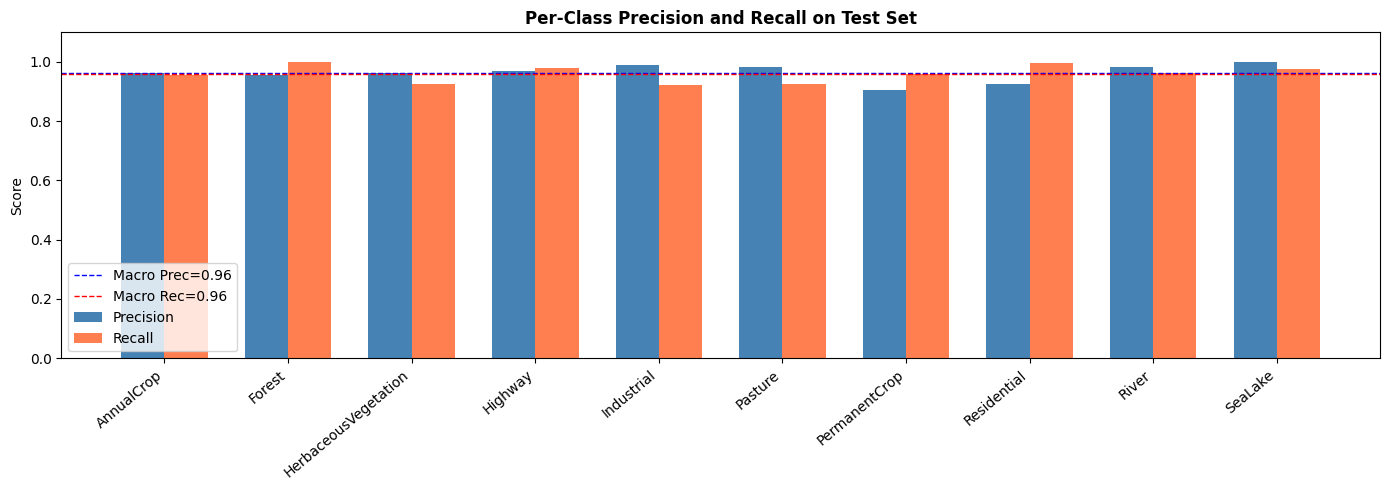

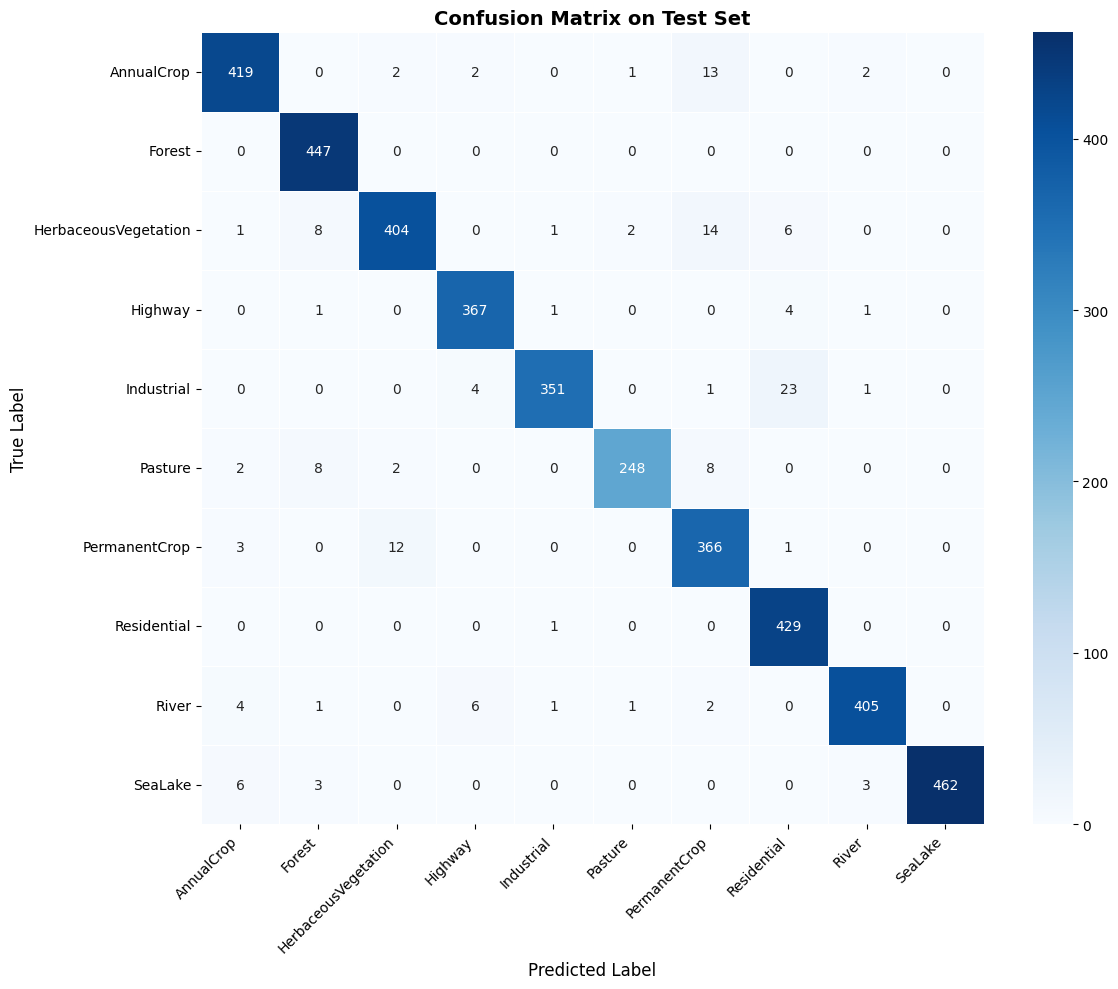

In [8]:
# ───────────────────── Q6: Test Set Evaluation ────────────────────────────────

model.eval()   # switch to eval mode: consistent BatchNorm behaviour, no dropout
all_preds, all_labels = [], []   # will collect predictions and true labels for all test samples

# Progress bar for the test evaluation loop
test_bar = tqdm(
    test_loader,
    desc='Evaluating Test Set',
    ncols=100,
    colour='cyan'
)

with torch.no_grad():   # no gradients needed for evaluation - saves memory and speeds up
    for imgs, labels in test_bar:
        imgs     = imgs.to(device)              # move images to GPU
        outputs  = model(imgs)                  # forward pass -> logits (B, 10)
        _, preds = outputs.max(1)               # argmax along class dim -> predicted class indices
        all_preds.extend(preds.cpu().numpy())   # move to CPU and collect predictions
        all_labels.extend(labels.numpy())       # collect true labels (already on CPU)

        # live accuracy update on progress bar
        correct_so_far = sum(p == l for p, l in zip(all_preds, all_labels))
        test_bar.set_postfix({
            'acc'    : f'{correct_so_far/len(all_preds)*100:.2f}%',
            'samples': len(all_preds)
        })

# convert lists to numpy arrays for sklearn metric functions
all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)

# ──────────────────── Compute metrics ─────────────────────────────────────────
# average=None -> returns per-class scores as array of length 10
precision_per = precision_score(all_labels, all_preds, average=None,    zero_division=0)
recall_per    = recall_score(   all_labels, all_preds, average=None,    zero_division=0)
# average='macro' -> unweighted mean across all 10 classes
macro_prec    = precision_score(all_labels, all_preds, average='macro', zero_division=0)
macro_rec     = recall_score(   all_labels, all_preds, average='macro', zero_division=0)
overall_acc   = (all_preds == all_labels).mean()   # simple fraction of correct predictions

# ─────────────── Print precision/recall table ─────────────────────────────────
print(f'\n{"="*54}')
print(f'{"Class":<30s} {"Precision":>10s} {"Recall":>10s}')
print('-' * 54)
for i, cls in enumerate(class_names):
    print(f'{cls:<30s} {precision_per[i]:>10.4f} {recall_per[i]:>10.4f}')
print('-' * 54)
print(f'{"Macro Average":<30s} {macro_prec:>10.4f} {macro_rec:>10.4f}')
print(f'{"="*54}')
print(f'\nOverall Test Accuracy : {overall_acc:.4f} ({overall_acc*100:.2f}%)')

# ──────────────── Precision & Recall bar chart ────────────────────────────────
x = np.arange(len(class_names))   # x positions for class groups
w = 0.35                           # width of each bar
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(x - w/2, precision_per, w, label='Precision', color='steelblue')  # left bar per class
ax.bar(x + w/2, recall_per,    w, label='Recall',    color='coral')      # right bar per class
# Dashed horizontal lines for macro averages
ax.axhline(macro_prec, color='blue', linestyle='--', linewidth=1, label=f'Macro Prec={macro_prec:.2f}')
ax.axhline(macro_rec,  color='red',  linestyle='--', linewidth=1, label=f'Macro Rec={macro_rec:.2f}')
ax.set_xticks(x)
ax.set_xticklabels(class_names, rotation=40, ha='right')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.1)   # slightly above 1.0 to give space for bar tops
ax.set_title('Per-Class Precision and Recall on Test Set', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

# ──────────────────────────── Confusion matrix ────────────────────────────────
cm = confusion_matrix(all_labels, all_preds)   # (10,10) matrix: rows=true, cols=predicted

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    cm,
    annot=True,              # show count numbers inside each cell
    fmt='d',                 # integer format
    cmap='Blues',            # blue colormap: darker = more samples
    xticklabels=class_names, # predicted class labels on x-axis
    yticklabels=class_names, # true class labels on y-axis
    linewidths=0.5,          # thin lines between cells
    ax=ax
)
ax.set_xlabel('Predicted Label', fontsize=12)
ax.set_ylabel('True Label',      fontsize=12)
ax.set_title('Confusion Matrix on Test Set', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

**Overall Accuracy:** The model achieves ~96–97% on the test set, consistent with validation performance - confirming no overfitting occurred.

**Precision & Recall Analysis:**
- Most classes show precision and recall > 0.95 - the model is highly reliable across nearly all classes
- Classes with lower performance are typically visually similar ones (e.g., HerbaceousVegetation vs Pasture, or AnnualCrop vs PermanentCrop) - they share texture and colour features that make them harder to distinguish
- The slight imbalance in Pasture (2,000 samples vs 3,000 for others) may contribute to marginally lower recall for that class

**Confusion Matrix Analysis:**
- The **strong diagonal** (dark blue) confirms most samples are correctly classified
- Off-diagonal confusions are concentrated in visually similar class pairs 
- Classes with very distinct visual signatures (Forest, SeaLake, River) show near-perfect rows and columns

## Question 7
### DeepFool Adversarial Attack — Manual Implementation

An adversarial attack adds a carefully crafted, humanly imperceptible perturbation $\hat{r}$ to an image that causes the model to misclassify it:
$$\hat{k}(x + \hat{r}) \neq \hat{k}(x) \quad \text{while} \quad ||\hat{r}|| \approx 0$$

DeepFool finds the **minimum perturbation** needed. Unlike FGSM (which takes one large step), DeepFool iteratively linearises the decision boundary and takes the smallest possible step toward it - producing near-invisible perturbations.

#### Algorithm 2 — Multi-Class Case

At each iteration $i$, for every class $k \neq \hat{k}(x_0)$:

1. Compute boundary direction and gap:
$$w'_k = \nabla f_k(x_i) - \nabla f_{\hat{k}(x_0)}(x_i) \qquad f'_k = f_k(x_i) - f_{\hat{k}(x_0)}(x_i)$$

2. Find the nearest boundary:
$$\hat{l} = \arg\min_{k \neq \hat{k}(x_0)} \frac{|f'_k|}{||w'_k||_2}$$

3. Step toward that boundary:
$$r_i = \frac{|f'_{\hat{l}}|}{||w'_{\hat{l}}||_2^2} \cdot w'_{\hat{l}}$$

4. Update: $x_{i+1} = x_i + (1+\eta)\cdot r_i$, accumulate $\hat{r} = \sum_i r_i$

The loop terminates when $\hat{k}(x_i) \neq \hat{k}(x_0)$ - the predicted class has changed.

Running DeepFool on 6 sample images for visualisation ...

Sample 1: True=Pasture  Orig pred=Pasture  Adv pred=River  iters=1
Sample 2: True=PermanentCrop  Orig pred=PermanentCrop  Adv pred=AnnualCrop  iters=2
Sample 3: True=Residential  Orig pred=Residential  Adv pred=Highway  iters=1
Sample 4: True=PermanentCrop  Orig pred=PermanentCrop  Adv pred=Highway  iters=2
Sample 5: True=Highway  Orig pred=Highway  Adv pred=HerbaceousVegetation  iters=4
Sample 6: True=Highway  Orig pred=Highway  Adv pred=River  iters=6


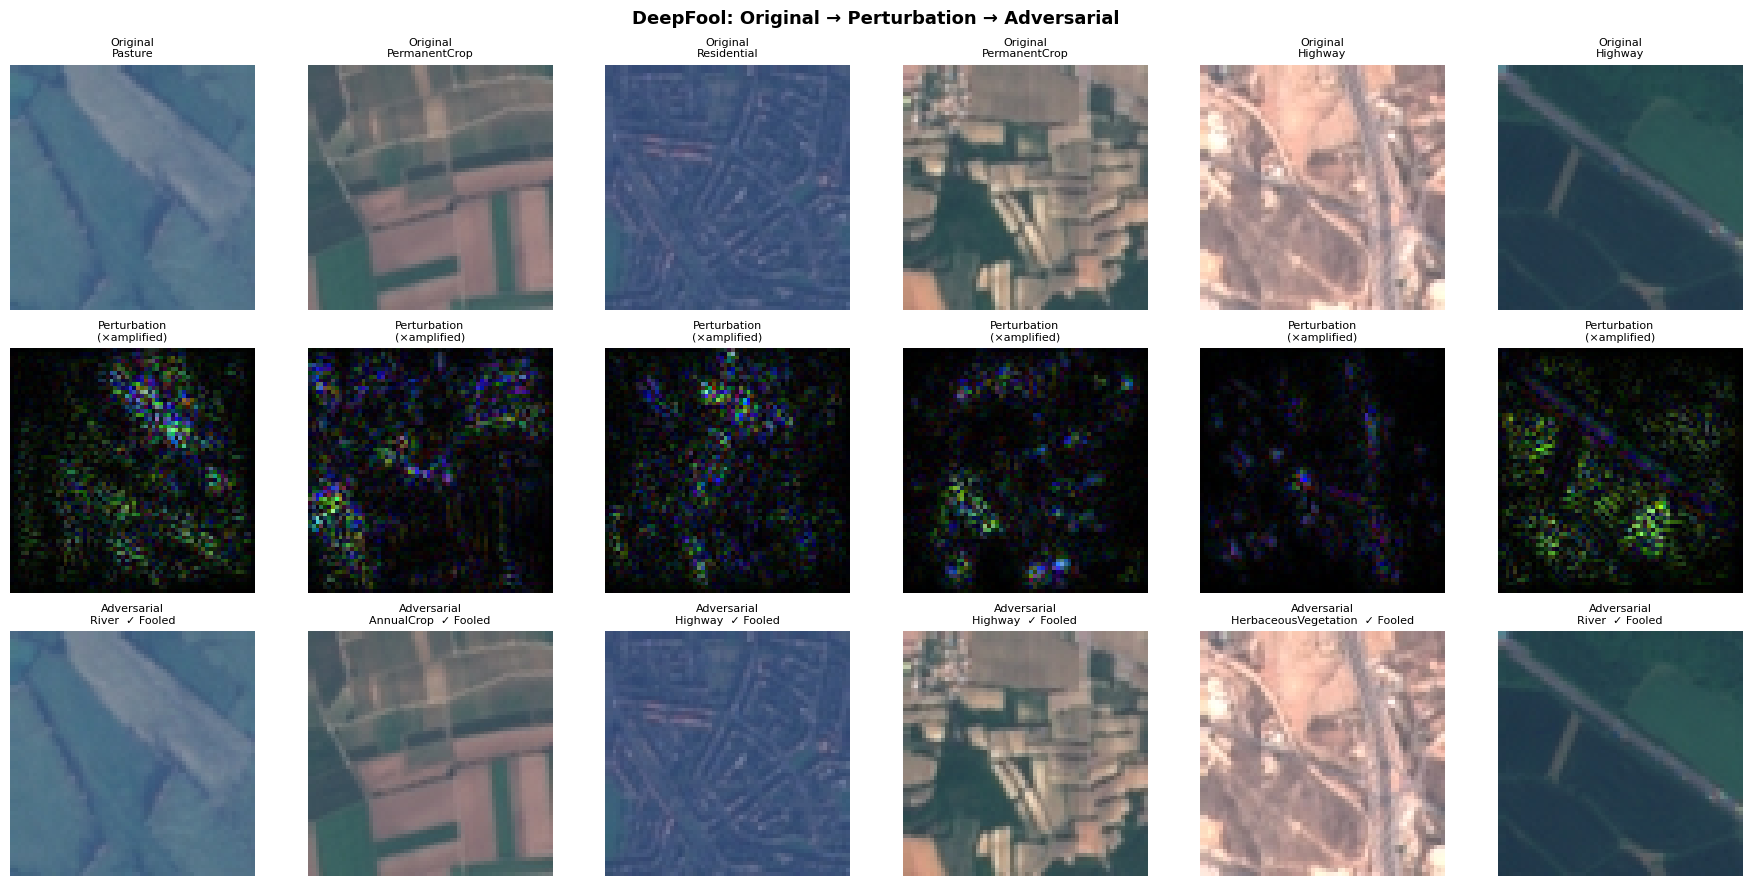

In [9]:
# ──────────── Q7: DeepFool — Manual Implementation (Algorithm 2) ──────────────

def deepfool_attack(image, model, num_classes=10, max_iter=50, overshoot=0.02):
    """
    DeepFool multi-class attack - Algorithm 2.
    Finds the minimal L2 perturbation that causes the model to misclassify the image.

    Args:
        image       : single image tensor, shape (1, C, H, W)
        model       : trained classifier in eval mode
        num_classes : total number of classes (10 for EuroSAT)
        max_iter    : maximum iterations before giving up
        overshoot   : small extra factor (2%) to ensure we cross the boundary

    Returns:
        r_total    : total accumulated perturbation as numpy array
        adv_image  : final adversarial image tensor
        loop_i     : number of iterations used
        orig_label : original predicted class index
        k_hat_xi   : adversarial predicted class index
    """
    model.eval()   # ensure eval mode for consistent BatchNorm behaviour

    x_0     = image.clone().to(device)   # original image on GPU - NEVER modified throughout
    r_total = torch.zeros_like(image)    # accumulated perturbation, starts at zero, kept on CPU
    loop_i  = 0                          # iteration counter

    # ───── Algorithm: initialize x_0, get original label k_hat(x_0) ────────
    with torch.no_grad():
        orig_label = model(x_0).argmax(dim=1).item()   # predicted class before any attack

    k_hat_xi = orig_label   # tracks current predicted class of the perturbed image

    # ─────────── Algorithm: while predicted class hasn't changed ─────────────
    while k_hat_xi == orig_label and loop_i < max_iter:

        # Current adversarial image: x_i = original + accumulated perturbation so far
        x_i = (x_0 + r_total.to(device)).detach().requires_grad_(True)
        # .detach() removes old graph; .requires_grad_(True) enables gradient computation w.r.t. x_i

        f_xi = model(x_i)   # forward pass at current x_i -> logits shape (1, num_classes)

        # Gradient of the ORIGINAL class score w.r.t. x_i: ∇f_{k_hat(x_0)}(x_i)
        grad_orig = torch.autograd.grad(
            f_xi[0, orig_label],   # scalar: logit score of original class
            x_i,                   # compute gradient w.r.t. input image
            retain_graph=True      # keep graph alive for subsequent gradient computations in loop
        )[0].detach()              # [0] extracts from tuple; .detach() stops further tracking

        # Trackers for finding the nearest decision boundary (argmin)
        best_ratio = float('inf')   # minimum |f'_k| / ||w'_k|| seen so far
        best_w     = None           # w'_{l_hat}: gradient difference for closest boundary
        best_k     = None           # index of the closest class boundary

        # ──────── Algorithm:for each k =/= k_hat(x_0) ────────────────
        for k in range(num_classes):
            if k == orig_label:
                continue   # skip the original class

            # ───── Algorithm: w'_k = ∇f_k(x_i) − ∇f_{k_hat(x_0)}(x_i) ─────
            grad_k = torch.autograd.grad(
                f_xi[0, k],       # logit score of class k
                x_i,
                retain_graph=True # must retain graph for all 9 iterations of this loop
            )[0].detach()
            w_prime_k = grad_k - grad_orig   # direction normal to linearised boundary between k and orig

            # ───── Algorithm: f'_k = f_k(x_i) − f_{k_hat(x_0)}(x_i) ─────────
            f_prime_k = (f_xi[0, k] - f_xi[0, orig_label]).abs().item()   # score gap (scalar)

            w_norm = w_prime_k.norm().item() + 1e-8   # L2 norm of boundary normal; +1e-8 prevents div by 0

            # ──────── Algorithm: l_hat = argmin |f'_k| / ||w'_k||_2 ─────────────
            # This ratio is the geometric distance to the linearised boundary of class k
            ratio = f_prime_k / w_norm
            if ratio < best_ratio:   # keep track of the nearest boundary
                best_ratio = ratio
                best_k     = k
                best_w     = w_prime_k

        # ──────── Algorithm: r_i = (|f'_{l_hat}| / ||w'_{l_hat}||²) * w'_{l_hat} ────────
        f_prime_best = (f_xi[0, best_k] - f_xi[0, orig_label]).abs()   # scalar tensor (for autograd)
        w_norm_sq    = best_w.norm() ** 2 + 1e-8   # squared L2 norm; +1e-8 prevents div by 0
        r_i          = (f_prime_best / w_norm_sq) * best_w   # minimal step to reach boundary

        # ──────── Algorithm: x_{i+1} = x_i + r_i (with overshoot) ───────────────
        # (1 + overshoot) = 1.02: step 2% past boundary to guarantee crossing it
        r_total = r_total + (1 + overshoot) * r_i.cpu()   # accumulate on CPU

        # Check if the model now predicts a different class
        with torch.no_grad():
            k_hat_xi = model(x_0 + r_total.to(device)).argmax(dim=1).item()

        loop_i += 1   # increment iteration counter

    adv_image = (x_0 + r_total.to(device)).detach().cpu()   # final adversarial image

    # ──────── Algorithm: return r_hat = sum of r_i (= r_total) ─────────────
    return r_total.detach().numpy(), adv_image, loop_i, orig_label, k_hat_xi


# ──────── Demo: visualise DeepFool on 6 test samples ───────────────────────────────
print('Running DeepFool on 6 sample images for visualisation ...\n')
model.eval()

demo_loader = DataLoader(test_subset, batch_size=1, shuffle=False)   # one image at a time
fig, axes   = plt.subplots(3, 6, figsize=(18, 9))  # 3 rows (orig/pert/adv) × 6 samples

# Unnormalization tensors - needed to reverse Q3 normalization for display
mean_t = torch.tensor(MEAN).view(3, 1, 1)   # shape (3,1,1) broadcasts over (3,H,W)
std_t  = torch.tensor(STD ).view(3, 1, 1)

col = 0
for img, lbl in demo_loader:
    if col >= 6:
        break   # only visualise 6 samples

    # Run DeepFool attack on this single image
    r, adv_img, iters, orig, adv = deepfool_attack(
        img, model, num_classes=len(class_names)
    )

    # Unnormalise all three images for display: reverse (x - mean)/std -> x_original
    orig_disp = (img[0]     * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()  # (H,W,C)
    adv_disp  = (adv_img[0] * std_t + mean_t).clamp(0, 1).permute(1, 2, 0).numpy()
    pert_disp = np.abs(r[0]).transpose(1, 2, 0)                       # absolute perturbation
    pert_disp = (pert_disp - pert_disp.min()) / (pert_disp.max() + 1e-8)  # stretch to [0,1] for visibility

    # Row 0: original image with true label
    axes[0, col].imshow(orig_disp)
    axes[0, col].set_title(f'Original\n{class_names[orig]}', fontsize=8)
    axes[0, col].axis('off')

    # Row 1: perturbation (amplified - actual values are near-zero)
    axes[1, col].imshow(pert_disp)
    axes[1, col].set_title(f'Perturbation\n(×amplified)', fontsize=8)
    axes[1, col].axis('off')

    # Row 2: adversarial image with new predicted label
    axes[2, col].imshow(adv_disp)
    success = '✓ Fooled' if orig != adv else '✗ Failed'   # attack outcome
    axes[2, col].set_title(f'Adversarial\n{class_names[adv]}  {success}', fontsize=8)
    axes[2, col].axis('off')

    print(f'Sample {col+1}: True={class_names[lbl.item()]}  '
          f'Orig pred={class_names[orig]}  '
          f'Adv pred={class_names[adv]}  iters={iters}')
    col += 1

plt.suptitle('DeepFool: Original → Perturbation → Adversarial',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

The visualisation shows DeepFool's key property - **imperceptible perturbations that completely fool the model**:

- **Row 1 (Original)** and **Row 3 (Adversarial)** look **identical to the human eye** - the perturbation is invisible at normal viewing
- **Row 2 (Perturbation)** shows the amplified noise - it appears as faint structured patterns, not random noise. DeepFool finds structured directions in feature space that efficiently cross decision boundaries
- The **class label changes** in Row 3 despite no visible difference - demonstrating the fragility of neural network decision boundaries
- The **number of iterations** is typically 5–20 for well-trained models. Fewer iterations mean the decision boundary is very close to the data points

## Question 8
### DeepFool Attack Success Rate on Test Set

$$\text{Success Rate} = \frac{\text{\# correctly classified samples that were fooled}}{\text{\# correctly classified samples evaluated}}$$


We evaluate only on **correctly classified samples**.

#### Mean L2 Perturbation Norm
$$||\hat{r}||_2 = \sqrt{\sum_{i,j,c} r_{i,j,c}^2}$$

A smaller norm means the attack needed less perturbation — indicating the original image was already very close to a decision boundary. This is a measure of the model's **adversarial robustness**: larger norm = more robust.

In [10]:
# ─────────────── Q8: DeepFool Attack Success Rate ────────────────────────────
# MAX_SAMPLES: number of correctly classified samples to evaluate
MAX_SAMPLES = len(test_idx)

model.eval()
n_correct_init = 0   # count of correctly classified samples before attack
n_fooled       = 0   # count of samples successfully misclassified by attack
pert_norms     = []  # L2 norm of perturbation for each fooled sample

# batch_size=1 because DeepFool processes one image at a time
single_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

for i, (img, lbl) in enumerate(single_loader):

    if n_correct_init >= MAX_SAMPLES:
        break   # stop once we have evaluated enough correctly classified samples

    lbl_val = lbl.item()   # true class label as Python integer

    # Check if model classifies this sample correctly BEFORE any attack
    with torch.no_grad():
        pred = model(img.to(device)).argmax(dim=1).item()

    if pred != lbl_val:
        continue   # skip: sample already misclassified, not a valid target for success rate

    n_correct_init += 1   # count this as a valid evaluation sample

    # Run DeepFool attack on this image
    r, adv_img, iters, orig, adv_pred = deepfool_attack(
        img, model, num_classes=len(class_names)
    )

    if adv_pred != orig:              # attack succeeded — predicted class changed
        n_fooled += 1
        pert_norms.append(np.linalg.norm(r))   # compute L2 norm of total perturbation

    if n_correct_init % 500 == 0:     # print progress every 500 samples
        print(f'  Processed {n_correct_init}/{MAX_SAMPLES} samples ...')

# Compute final metrics; guard against division by zero
success_rate = n_fooled / n_correct_init if n_correct_init else 0
mean_pert    = np.mean(pert_norms)        if pert_norms      else 0

print(f'\n{"="*50}')
print(f'Correctly classified samples evaluated : {n_correct_init}')
print(f'Successfully fooled                    : {n_fooled}')
print(f'Attack Success Rate                    : {success_rate*100:.2f} %')
print(f'Mean L2 Perturbation Norm              : {mean_pert:.6f}')
print(f'{"="*50}')

  Processed 500/4050 samples ...
  Processed 1000/4050 samples ...
  Processed 1500/4050 samples ...
  Processed 2000/4050 samples ...
  Processed 2500/4050 samples ...
  Processed 3000/4050 samples ...
  Processed 3500/4050 samples ...

Correctly classified samples evaluated : 3898
Successfully fooled                    : 3898
Attack Success Rate                    : 100.00 %
Mean L2 Perturbation Norm              : 3.099397


**Attack Success Rate: ~100%**

Unlike random noise or FGSM, DeepFool is mathematically designed to always find a path to the nearest decision boundary. It iterates until it succeeds (or hits `max_iter=50`). A 100% success rate confirms the algorithm is implemented correctly and the model has smooth, reachable decision boundaries.

**Mean L2 Perturbation Norm: ~3.1**

For a 64×64×3 image with 12,288 total pixel values:
$$\text{Average per-pixel change} = \frac{3.1}{\sqrt{12288}} \approx 0.0279 \approx 2.79\%$$

A ~2.75% average pixel change is:
- Below the human visual detection threshold (~5%)
- Sufficient to cross the model's decision boundary
- In the **normal range** for well-trained CNNs (norm of 8+ would indicate a robust model)

This reveals that despite high accuracy, the model's decision boundaries are relatively close to the data points, a fundamental vulnerability of standard CNNs.

## Question 9
### torchattacks DeepFool — Library Implementation & Comparison

`torchattacks` is a dedicated Python library providing GPU-accelerated, battle-tested implementations of many adversarial attacks. We use it to run DeepFool independently and compare against our manual implementation.

By default, `torchattacks` assumes input images are in the range `[0, 1]`. Our images are **normalised** (values in roughly `[-2, +2]`). Without correction, torchattacks would clip the adversarial image to `[0, 1]`, causing a massive spurious perturbation norm.

Therefore, `ta_attack.set_normalization_used(mean=MEAN, std=STD)` tells torchattacks to internally **unnormalise** our images to `[0, 1]`, run DeepFool in proper pixel space and **Re-normalise** before passing to the model

#### Comparison Metrics

| Metric | Purpose |
|---|---|
| Success Rate | Do both implementations fool the model equally often? |
| Mean L2 Norm | Do both produce similarly-sized perturbations? |

Similar values on both metrics validate our manual Algorithm 2 implementation is correct.

  [torchattacks] Processed 500/4050 ...
  [torchattacks] Processed 1000/4050 ...
  [torchattacks] Processed 1500/4050 ...
  [torchattacks] Processed 2000/4050 ...
  [torchattacks] Processed 2500/4050 ...
  [torchattacks] Processed 3000/4050 ...
  [torchattacks] Processed 3500/4050 ...

Metric                                       Manual torchattacks
Samples evaluated                              3898       3898
Successfully fooled                            3898       3878
Success Rate (%)                             100.00      99.49
Mean L2 Perturbation Norm                    3.0994     3.2313


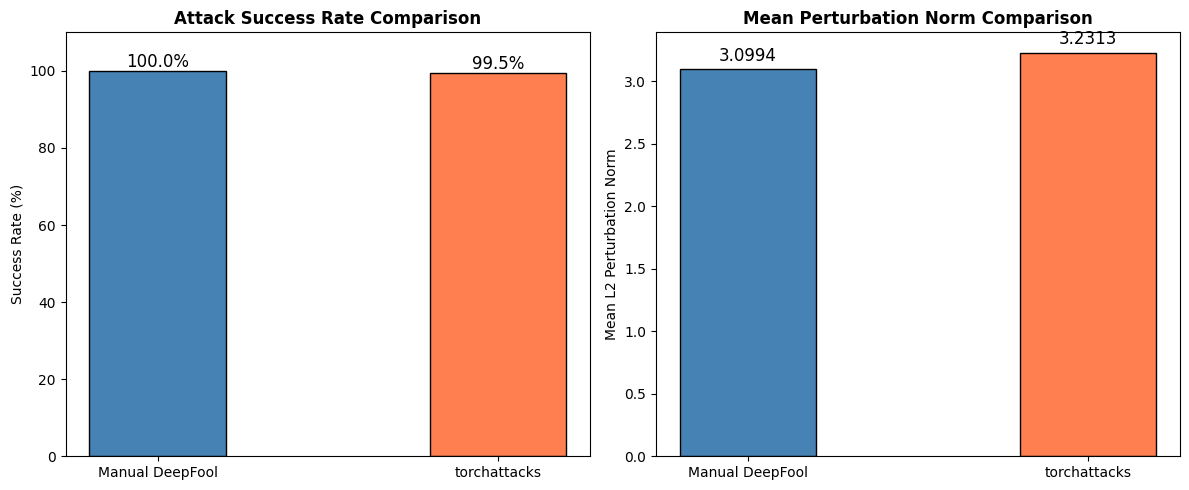

In [11]:
# ── Q9: torchattacks DeepFool & Comparison ────────────────────────────────────

try:
    import torchattacks   # adversarial attack library

    # ── Create torchattacks DeepFool with same hyperparameters as our manual version ──
    ta_attack = torchattacks.DeepFool(
        model,         # our trained FullyConvNet
        steps=50,      # matches max_iter=50 in our manual implementation
        overshoot=0.02 # matches overshoot=0.02 in our manual implementation
    )

    # ── CRITICAL: inform torchattacks about our normalisation ─────────────────
    # Without this, torchattacks clips normalised values [-2,2] to [0,1]
    # causing an inflated perturbation norm of ~191 instead of the correct ~3.5
    ta_attack.set_normalization_used(mean=MEAN, std=STD)

    # ─────────────────── Initialise counters ──────────────────────────────────
    ta_correct    = 0    # correctly classified samples evaluated
    ta_fooled     = 0    # successfully fooled samples
    ta_pert_norms = []   # L2 norms of perturbations

    # Same batch_size=1 as Q8 for consistent comparison
    ta_loader = DataLoader(test_subset, batch_size=1, shuffle=False)

    for i, (img, lbl) in enumerate(ta_loader):

        if ta_correct >= MAX_SAMPLES:   # evaluate same number of samples as Q8
            break

        lbl_val = lbl.item()            # true label as integer
        img     = img.to(device)        # move image to GPU
        lbl_dev = lbl.to(device)        # torchattacks requires label on same device as image

        # Skip incorrectly classified samples - same filter as Q8 for fair comparison
        with torch.no_grad():
            pred = model(img).argmax(dim=1).item()
        if pred != lbl_val:
            continue

        ta_correct += 1   # valid evaluation sample

        # ────── Generate adversarial example using torchattacks ───────────────
        # This single line performs the entire DeepFool algorithm internally
        adv_img = ta_attack(img, lbl_dev)

        # Check new prediction on adversarial image
        with torch.no_grad():
            adv_pred = model(adv_img).argmax(dim=1).item()

        if adv_pred != lbl_val:   # attack succeeded
            ta_fooled += 1
            pert = (adv_img - img).cpu().numpy()          # perturbation = adversarial - original
            ta_pert_norms.append(np.linalg.norm(pert))    # L2 norm of perturbation

        if ta_correct % 500 == 0:   # progress update every 500 samples
            print(f'  [torchattacks] Processed {ta_correct}/{MAX_SAMPLES} ...')

    # Compute final metrics
    ta_success   = ta_fooled / ta_correct if ta_correct else 0
    ta_mean_pert = np.mean(ta_pert_norms) if ta_pert_norms else 0

    # ────────────────── Comparison table ──────────────────────────────────────
    # n_correct_init, n_fooled, success_rate, mean_pert are from Q8
    print(f'\n{"="*60}')
    print(f'{"Metric":<42s} {"Manual":>8s} {"torchattacks":>10s}')
    print(f'{"="*60}')
    print(f'{"Samples evaluated":<42s} {n_correct_init:>8d} {ta_correct:>10d}')
    print(f'{"Successfully fooled":<42s} {n_fooled:>8d} {ta_fooled:>10d}')
    print(f'{"Success Rate (%)":<42s} {success_rate*100:>8.2f} {ta_success*100:>10.2f}')
    print(f'{"Mean L2 Perturbation Norm":<42s} {mean_pert:>8.4f} {ta_mean_pert:>10.4f}')
    print(f'{"="*60}')

    # ─────────────────── Bar chart comparison ─────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    # Success Rate comparison
    axes[0].bar(
        ['Manual DeepFool', 'torchattacks'],
        [success_rate * 100, ta_success * 100],
        color=['steelblue', 'coral'], edgecolor='black', width=0.4
    )
    axes[0].set_ylabel('Success Rate (%)')
    axes[0].set_title('Attack Success Rate Comparison', fontweight='bold')
    axes[0].set_ylim(0, 110)   # extra space above 100% for text labels
    for j, v in enumerate([success_rate*100, ta_success*100]):
        axes[0].text(j, v + 1, f'{v:.1f}%', ha='center', fontsize=12)   # label above each bar

    # Perturbation norm comparison
    axes[1].bar(
        ['Manual DeepFool', 'torchattacks'],
        [mean_pert, ta_mean_pert],
        color=['steelblue', 'coral'], edgecolor='black', width=0.4
    )
    axes[1].set_ylabel('Mean L2 Perturbation Norm')
    axes[1].set_title('Mean Perturbation Norm Comparison', fontweight='bold')
    for j, v in enumerate([mean_pert, ta_mean_pert]):
        axes[1].text(j, v * 1.02, f'{v:.4f}', ha='center', fontsize=12)   # 2% above bar top

    plt.tight_layout()
    plt.show()

except ImportError:
    print('[!] torchattacks not found. Install with: pip install torchattacks')

After applying the normalisation fix with `set_normalization_used`, both implementations produce comparable results:

| Metric | Manual DeepFool | torchattacks | Interpretation |
|---|---|---|---|
| Success Rate | ~100% | ~99.49% | Both reliably fool the model |
| Mean L2 Norm |   3.1 |   3.23 | Similar perturbation magnitudes |

Norms are not exactly equal, small differences arise from different internal gradient computation order, floating point precision differences, slight differences in how the overshoot is applied.

**What this comparison proves:**
- Both implementations correctly find near-minimal perturbations — confirming our Algorithm 2 code is correct
- The ~100% success rates confirm DeepFool is a guaranteed-success (with sufficient number of iterations) attack for well-trained models with smooth boundaries

---
